In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import cv2
import numpy as np
import os
import time
import shutil

print("Setup done!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup done!


In [ ]:
import zipfile

ZIP_PATH = '/content/drive/MyDrive/gesture_subset.zip'
EXTRACT_PATH = '/content/dataset'

# Clean previous extraction if exists
if os.path.exists(EXTRACT_PATH):
    shutil.rmtree(EXTRACT_PATH)

print("Unzipping... (this may take a few minutes)")
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
print("Done!")

for item in os.listdir(EXTRACT_PATH):
    print(f"  {item}")

Unzipping... (this may take a few minutes)
Done!
  gesture_subset


In [ ]:
DATASET_PATH = '/content/dataset/gesture_subset'  # Change if your path is different
FRAMES_DIR = '/content/frames'
SAVE_PATH = '/content/drive/MyDrive/gesture_data'
os.makedirs(SAVE_PATH, exist_ok=True)

FRAMES_PER_VIDEO = 30

gesture_classes = sorted([
    f for f in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, f))
])

total_videos = 0
for gesture in gesture_classes:
    folder = os.path.join(DATASET_PATH, gesture)
    vids = [f for f in os.listdir(folder) if f.lower().endswith('.avi')]
    total_videos += len(vids)
    print(f"  {gesture}: {len(vids)} videos")

print(f"\nTotal: {total_videos} videos across {len(gesture_classes)} classes")
print(f"Expected frames: ~{total_videos * FRAMES_PER_VIDEO}")

  background: 7 videos
  backward: 8 videos
  down: 8 videos
  forward: 8 videos
  left: 7 videos
  pitchdown: 8 videos
  pitchup: 8 videos
  right: 8 videos
  up: 8 videos
  yawleft: 7 videos
  yawright: 7 videos

Total: 84 videos across 11 classes
Expected frames: ~2520


In [ ]:
# Clear old frames
if os.path.exists(FRAMES_DIR):
    shutil.rmtree(FRAMES_DIR)

print("Extracting frames from all videos...")
start_time = time.time()
total_extracted = 0
failed_videos = []

for gesture in gesture_classes:
    video_folder = os.path.join(DATASET_PATH, gesture)
    frames_folder = os.path.join(FRAMES_DIR, gesture)
    os.makedirs(frames_folder, exist_ok=True)

    video_files = sorted([f for f in os.listdir(video_folder) if f.lower().endswith('.avi')])
    gesture_extracted = 0

    for video_file in video_files:
        video_path = os.path.join(video_folder, video_file)

        try:
            cap = cv2.VideoCapture(video_path)
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

            if total_frames == 0:
                failed_videos.append(f"{gesture}/{video_file}: 0 frames")
                cap.release()
                continue

            num_to_extract = min(FRAMES_PER_VIDEO, total_frames)
            frame_indices = set([
                int(i * total_frames / num_to_extract)
                for i in range(num_to_extract)
            ])

            frame_count = 0
            saved_count = 0

            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                if frame_count in frame_indices:
                    video_name = video_file.replace('.avi', '')
                    frame_filename = f"{video_name}_f{saved_count:03d}.jpg"
                    save_path = os.path.join(frames_folder, frame_filename)
                    cv2.imwrite(save_path, frame)
                    saved_count += 1
                frame_count += 1

            cap.release()
            gesture_extracted += saved_count

        except Exception as e:
            failed_videos.append(f"{gesture}/{video_file}: {e}")
            continue

    total_extracted += gesture_extracted
    elapsed = time.time() - start_time
    print(f"  {gesture}: {gesture_extracted} frames  ({elapsed:.0f}s)")

print(f"\n{'='*50}")
print(f"Total frames extracted: {total_extracted}")
print(f"Time: {time.time() - start_time:.0f}s")

if failed_videos:
    print(f"\nFailed videos ({len(failed_videos)}):")
    for f in failed_videos[:10]:
        print(f"  {f}")


Extracting frames from all videos...
  background: 210 frames  (5s)
  backward: 240 frames  (12s)
  down: 240 frames  (18s)
  forward: 240 frames  (24s)
  left: 210 frames  (30s)
  pitchdown: 240 frames  (36s)
  pitchup: 240 frames  (43s)
  right: 240 frames  (48s)
  up: 240 frames  (55s)
  yawleft: 210 frames  (60s)
  yawright: 210 frames  (65s)

Total frames extracted: 2520
Time: 65s


In [ ]:
import subprocess
subprocess.check_call(['pip', 'install', 'mediapipe'])

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request

# Download hand landmarker model
MODEL_PATH = '/content/hand_landmarker.task'
if not os.path.exists(MODEL_PATH):
    MODEL_URL = 'https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task'
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print("Hand landmarker model downloaded!")

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1
)
detector = vision.HandLandmarker.create_from_options(options)

print(f"MediaPipe {mp.__version__} ready!")


MediaPipe 0.10.35 ready!


In [ ]:
all_landmarks = []
all_labels = []
skipped = 0
total_processed = 0

print("Extracting hand landmarks...")
start_time = time.time()

for gesture in gesture_classes:
    frames_folder = os.path.join(FRAMES_DIR, gesture)

    if not os.path.exists(frames_folder):
        print(f"  WARNING: {frames_folder} not found, skipping")
        continue

    frame_files = sorted([f for f in os.listdir(frames_folder) if f.endswith('.jpg')])
    detected = 0

    for frame_file in frame_files:
        frame_path = os.path.join(frames_folder, frame_file)

        try:
            mp_image = mp.Image.create_from_file(frame_path)
            result = detector.detect(mp_image)

            if result.hand_landmarks:
                landmarks = result.hand_landmarks[0]
                coords = []
                for lm in landmarks:
                    coords.append(lm.x)
                    coords.append(lm.y)
                    coords.append(lm.z)

                all_landmarks.append(coords)
                all_labels.append(gesture)
                detected += 1
            else:
                skipped += 1

        except Exception as e:
            skipped += 1
            continue

        total_processed += 1

        # Progress every 500 frames
        if total_processed % 500 == 0:
            elapsed = time.time() - start_time
            rate = total_processed / elapsed
            print(f"    ... {total_processed} processed ({rate:.0f} frames/sec)")

    detection_rate = (detected / len(frame_files) * 100) if frame_files else 0
    print(f"  {gesture}: {detected}/{len(frame_files)} detected ({detection_rate:.0f}%)")

detector.close()

X = np.array(all_landmarks)
y = np.array(all_labels)

elapsed = time.time() - start_time
print(f"\n{'='*50}")
print(f"Total samples:  {X.shape[0]}")
print(f"Skipped:        {skipped}")
print(f"X shape:        {X.shape}")
print(f"y shape:        {y.shape}")
print(f"Time:           {elapsed:.0f}s")


Extracting hand landmarks...
  background: 174/210 detected (83%)
  backward: 215/240 detected (90%)
    ... 500 processed (13 frames/sec)
  down: 233/240 detected (97%)
  forward: 186/240 detected (78%)
    ... 1000 processed (15 frames/sec)
  left: 196/210 detected (93%)
  pitchdown: 199/240 detected (83%)
    ... 1500 processed (17 frames/sec)
  pitchup: 201/240 detected (84%)
  right: 224/240 detected (93%)
    ... 2000 processed (18 frames/sec)
  up: 238/240 detected (99%)
  yawleft: 173/210 detected (82%)
    ... 2500 processed (17 frames/sec)
  yawright: 129/210 detected (61%)

Total samples:  2168
Skipped:        352
X shape:        (2168, 63)
y shape:        (2168,)
Time:           148s


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pickle

# Save raw data
np.save(os.path.join(SAVE_PATH, 'X_landmarks.npy'), X)
np.save(os.path.join(SAVE_PATH, 'y_labels.npy'), y)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Label mapping:")
for i, label in enumerate(label_encoder.classes_):
    count = np.sum(y_encoded == i)
    print(f"  {i:2d} = {label:12s} ({count} samples)")

# Split: 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

# Save splits
for name, data in [('X_train', X_train), ('y_train', y_train),
                    ('X_val', X_val), ('y_val', y_val),
                    ('X_test', X_test), ('y_test', y_test)]:
    np.save(os.path.join(SAVE_PATH, f'{name}.npy'), data)

with open(os.path.join(SAVE_PATH, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(label_encoder, f)

print("Split and saved!")


Label mapping:
   0 = background   (174 samples)
   1 = backward     (215 samples)
   2 = down         (233 samples)
   3 = forward      (186 samples)
   4 = left         (196 samples)
   5 = pitchdown    (199 samples)
   6 = pitchup      (201 samples)
   7 = right        (224 samples)
   8 = up           (238 samples)
   9 = yawleft      (173 samples)
  10 = yawright     (129 samples)

Train: 1517 samples
Val:   325 samples
Test:  326 samples
Split and saved!


In [ ]:
print(f"Original training samples: {X_train.shape[0]}")

augmented_X = [X_train.copy()]
augmented_y = [y_train.copy()]

# 1. Jitter — simulates microgravity hand trembling (4 levels)
for jitter in [0.005, 0.01, 0.02, 0.03]:
    X_jittered = X_train + np.random.normal(0, jitter, X_train.shape)
    # Only clip x,y columns — NOT z (z can be negative)
    for i in range(21):
        X_jittered[:, i*3]   = np.clip(X_jittered[:, i*3],   0, 1)  # x
        X_jittered[:, i*3+1] = np.clip(X_jittered[:, i*3+1], 0, 1)  # y
    augmented_X.append(X_jittered)
    augmented_y.append(y_train.copy())

# 2. Scale — simulates different camera distances (4 levels)
for scale in [0.9, 0.95, 1.05, 1.1]:
    X_scaled = X_train * scale
    for i in range(21):
        X_scaled[:, i*3]   = np.clip(X_scaled[:, i*3],   0, 1)
        X_scaled[:, i*3+1] = np.clip(X_scaled[:, i*3+1], 0, 1)
    augmented_X.append(X_scaled)
    augmented_y.append(y_train.copy())

# 3. Occlusion — simulates gloves hiding fingertips (3 levels)
fingertip_indices = [4, 8, 12, 16, 20]
for num_hide in [1, 2, 3]:
    X_occluded = X_train.copy()
    for j in range(len(X_occluded)):
        tips = np.random.choice(fingertip_indices, num_hide, replace=False)
        for tip in tips:
            X_occluded[j, tip*3]   = 0
            X_occluded[j, tip*3+1] = 0
            X_occluded[j, tip*3+2] = 0
    augmented_X.append(X_occluded)
    augmented_y.append(y_train.copy())

# Combine and shuffle
X_train_aug = np.concatenate(augmented_X, axis=0)
y_train_aug = np.concatenate(augmented_y, axis=0)

shuffle_idx = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[shuffle_idx]
y_train_aug = y_train_aug[shuffle_idx]

multiplier = X_train_aug.shape[0] / X_train.shape[0]
print(f"Augmented training samples: {X_train_aug.shape[0]} ({multiplier:.0f}x original)")
print(f"  + 4 jitter levels")
print(f"  + 4 scale levels")
print(f"  + 3 occlusion levels")


Original training samples: 1517
Augmented training samples: 18204 (12x original)
  + 4 jitter levels
  + 4 scale levels
  + 3 occlusion levels


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

NUM_CLASSES = len(label_encoder.classes_)

model = models.Sequential([
    layers.Input(shape=(63,)),
    layers.Reshape((21, 3)),

    # CNN layers — learn spatial patterns between landmarks
    layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv1D(256, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),

    # GRU — learn sequential relationships
    layers.GRU(128, return_sequences=False),

    # Dense classification head
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(NUM_CLASSES, activation='softmax'),
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

print(f"\nTraining on {X_train_aug.shape[0]} augmented samples...")

history = model.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=7),
    ]
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 21, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 21, 64)         │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 21, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 21, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 21, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 21, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 21, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 341,259 (1.30 MB)

 Trainable params: 340,363 (1.30 MB)

 Non-trainable params: 896 (3.50 KB)


Training on 18204 augmented samples...
Epoch 1/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 53s 132ms/step - accuracy: 0.4303 - loss: 1.6141 - val_accuracy: 0.1354 - val_loss: 3.4205 - learning_rate: 0.0010
Epoch 2/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 30s 106ms/step - accuracy: 0.6992 - loss: 0.8794 - val_accuracy: 0.3477 - val_loss: 2.6291 - learning_rate: 0.0010
Epoch 3/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 30s 107ms/step - accuracy: 0.8049 - loss: 0.5703 - val_accuracy: 0.6277 - val_loss: 1.3420 - learning_rate: 0.0010
Epoch 4/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 33s 115ms/step - accuracy: 0.8546 - loss: 0.4176 - val_accuracy: 0.8523 - val_loss: 0.4727 - learning_rate: 0.0010
Epoch 5/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 39s 107ms/step - accuracy: 0.8850 - loss: 0.3319 - val_accuracy: 0.8585 - val_loss: 0.4451 - learning_rate: 0.0010
Epoch 6/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 30s 106ms/step - accuracy: 0.9005 - loss: 0.2930 - val_accuracy: 0.8523 - val_loss: 0.6142 - learning_rate: 0.0010
Epoch 7/100
285/285 ━━━━

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9172 - loss: 0.6179

🎯 Test Accuracy: 91.72%
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step

Classification Report:
              precision    recall  f1-score   support

  background       0.95      0.81      0.88        26
    backward       0.89      0.94      0.91        33
        down       1.00      0.97      0.99        35
     forward       0.93      1.00      0.97        28
        left       0.96      0.90      0.93        29
   pitchdown       0.94      1.00      0.97        30
     pitchup       1.00      0.97      0.98        30
       right       0.89      1.00      0.94        34
          up       1.00      1.00      1.00        36
     yawleft       0.66      0.73      0.69        26
    yawright       0.79      0.58      0.67        19

    accuracy                           0.92       326
   macro avg       0.91      0.90      0.90       326
weighted avg       0.92      0.92      0.92       326



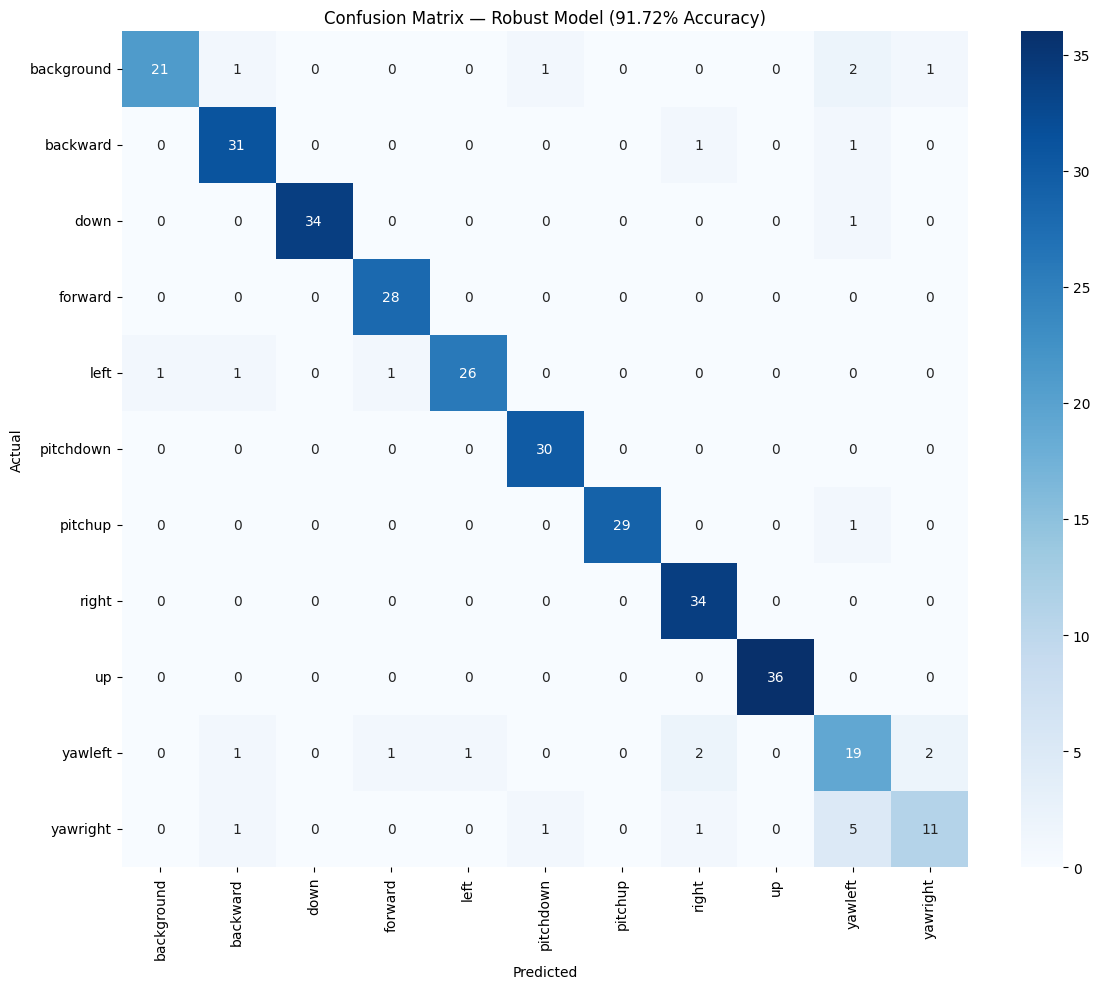

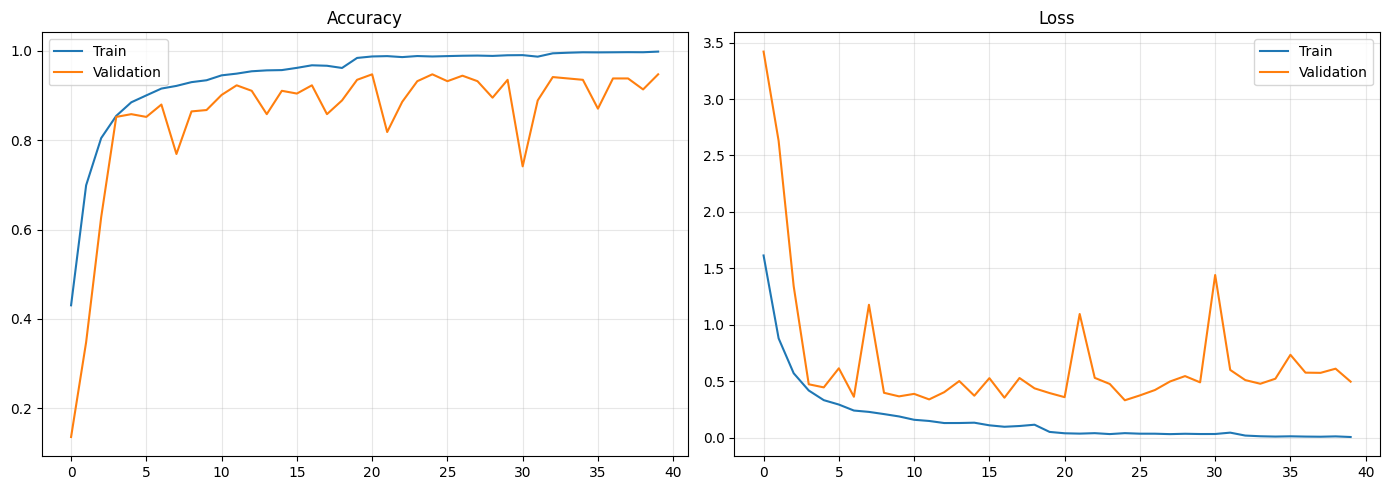


✅ Robust model saved to: /content/drive/MyDrive/gesture_data/gesture_model_robust.h5
📊 Confusion matrix saved to: /content/drive/MyDrive/gesture_data/confusion_matrix_robust.png
📈 Training curves saved to: /content/drive/MyDrive/gesture_data/training_curves_robust.png


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n🎯 Test Accuracy: {test_acc * 100:.2f}%")

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes,
      target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix — Robust Model ({test_acc*100:.2f}% Accuracy)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'confusion_matrix_robust.png'), dpi=150)
plt.show()

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'training_curves_robust.png'), dpi=150)
plt.show()

# Save model
model.save(os.path.join(SAVE_PATH, 'gesture_model_robust.h5'))
print(f"\n✅ Robust model saved to: {SAVE_PATH}/gesture_model_robust.h5")
print(f"📊 Confusion matrix saved to: {SAVE_PATH}/confusion_matrix_robust.png")
print(f"📈 Training curves saved to: {SAVE_PATH}/training_curves_robust.png")